# Análise de Classificação Supervisionada para Detecção de Doença Cardíaca
Este notebook apresenta um guia completo, passo a passo, para realizar uma análise de classificação supervisionada utilizando ferramentas clássicas do ecossistema Python.

In [ ]:
# ============================================================
# 1. IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas do Scikit-Learn para modelagem e pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Algoritmos de classificação
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [ ]:
# ============================================================
# 2. CARREGAMENTO DA BASE DE DADOS
# ============================================================
from google.colab import files

print("Por favor, faça o upload do arquivo .xlsx contendo a base de dados:")
uploaded = files.upload()

# Carrega automaticamente o primeiro arquivo carregado no dicionário
nome_arquivo = list(uploaded.keys())[0]
df = pd.read_excel(nome_arquivo)

# Apresentação dos dados solicitados
print("\n--- Primeiras 5 linhas da base de dados ---")
display(df.head())

print(f"\nDimensões da base: {df.shape[0]} observações e {df.shape[1]} colunas.")

print("\n--- Tipos das variáveis ---")
print(df.dtypes)

print("\n--- Quantidade de valores ausentes por variável ---")
print(df.isnull().sum())

Por favor, faça o upload do arquivo .xlsx contendo a base de dados:


Saving DadosCoracao.xlsx to DadosCoracao.xlsx

--- Primeiras 5 linhas da base de dados ---


,Idade,Sexo,DorPeito,PSDescanso,Colesterol,AcucarSangue,ECGDescanso,BCMax,AnginaExercicio,DoencaCard
0,40,Masculino,Atipica,140,289,Normal,Normal,172,Nao,Nao
1,49,Feminino,Sem_Dor,160,180,Normal,Normal,156,Nao,Sim
2,37,Masculino,Atipica,130,283,Normal,Anormal_ST,98,Nao,Nao
3,48,Feminino,Assintomatico,138,214,Normal,Normal,108,Sim,Sim
4,54,Masculino,Sem_Dor,150,195,Normal,Normal,122,Nao,Nao



Dimensões da base: 746 observações e 10 colunas.

--- Tipos das variáveis ---
Idade               int64
Sexo               object
DorPeito           object
PSDescanso          int64
Colesterol          int64
AcucarSangue       object
ECGDescanso        object
BCMax               int64
AnginaExercicio    object
DoencaCard         object
dtype: object

--- Quantidade de valores ausentes por variável ---
Idade              0
Sexo               0
DorPeito           0
PSDescanso         0
Colesterol         0
AcucarSangue       0
ECGDescanso        0
BCMax              0
AnginaExercicio    0
DoencaCard         0
dtype: int64


In [ ]:
# ============================================================
# 3. DEFINIÇÃO DAS VARIÁVEIS E AJUSTE DOS TIPOS
# ============================================================
# Definindo variáveis numéricas e categóricas explicativas
colunas_numericas = ['Idade', 'PSDescanso', 'Colesterol', 'BCMax']
colunas_categoricas = ['Sexo', 'DorPeito', 'AcucarSangue', 'ECGDescanso', 'AnginaExercicio']

# Garantindo explicitamente os tipos de dados adequados
for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in colunas_categoricas:
    df[col] = df[col].astype(str)

# Separação em explicativas (X) e resposta (y)
X = df[colunas_numericas + colunas_categoricas].copy()

# Mapeamento e tratamento da variável resposta
# Nao = 0, Sim = 1 (Classe positiva para métricas de avaliação)
y = df['DoencaCard'].map({'Nao': 0, 'Sim': 1})

print("Variáveis explicativas (X) e resposta (y) definidas com sucesso!")
print(f"Distribuição da variável resposta (contagem):\n{y.value_counts()}")

Variáveis explicativas (X) e resposta (y) definidas com sucesso!
Distribuição da variável resposta (contagem):
DoencaCard
0    390
1    356
Name: count, dtype: int64


In [ ]:
# ============================================================
# 4. DIVISÃO EM TREINAMENTO E TESTE
# ============================================================
# Divisão estratificada: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Observações no conjunto de treinamento: {X_train.shape[0]}")
print(f"Observações no conjunto de teste: {X_test.shape[0]}\n")

# Distribuição percentual das classes em cada divisão
print("Proporção das classes no conjunto de TREINAMENTO:")
print(y_train.value_counts(normalize=True) * 100)

print("\nProporção das classes no conjunto de TESTE:")
print(y_test.value_counts(normalize=True) * 100)

Observações no conjunto de treinamento: 596
Observações no conjunto de teste: 150

Proporção das classes no conjunto de TREINAMENTO:
DoencaCard
0    52.348993
1    47.651007
Name: proportion, dtype: float64

Proporção das classes no conjunto de TESTE:
DoencaCard
0    52.0
1    48.0
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 5. ESTRUTURAÇÃO DO PRÉ-PROCESSAMENTO (PIPELINE)
# ============================================================
# Padronização para atributos numéricos
transformador_numerico = StandardScaler()

# One-Hot Encoding para atributos categóricos
transformador_categorico = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Unificando o pré-processamento com ColumnTransformer
pre_processamento = ColumnTransformer(
    transformers=[
        ('num', transformador_numerico, colunas_numericas),
        ('cat', transformador_categorico, colunas_categoricas)
    ]
)

print("Estrutura do pipeline de pré-processamento configurada!")

Estrutura do pipeline de pré-processamento configurada!


In [ ]:
# ============================================================
# 6. ESCOLHA DOS ALGORITMOS PELO USUÁRIO
# ============================================================
# Dicionário mapeando os algoritmos disponíveis
algoritmos_disponiveis = {
    '1': ('Árvore de Decisão', DecisionTreeClassifier(random_state=42)),
    '2': ('SVM', SVC(probability=True, random_state=42)),
    '3': ('Naive Bayes', GaussianNB()),
    '4': ('kNN', KNeighborsClassifier()),
    '5': ('Random Forest', RandomForestClassifier(random_state=42))
}

print("Escolha dois algoritmos para comparação:\n")
for chave, valor in algoritmos_disponiveis.items():
    print(f"{chave} - {valor[0]}")
print()

# Validação da entrada do primeiro algoritmo
while True:
    op1 = input("Primeiro algoritmo (digite de 1 a 5): ").strip()
    if op1 in algoritmos_disponiveis:
        break
    print("Opção inválida! Escolha um número entre 1 e 5.")

# Validação da entrada do segundo algoritmo
while True:
    op2 = input("Segundo algoritmo (digite de 1 a 5): ").strip()
    if op2 == op1:
        print("Erro: Você não pode escolher o mesmo algoritmo duas vezes.")
    elif op2 in algoritmos_disponiveis:
        break
    else:
        print("Opção inválida! Escolha um número entre 1 e 5.")

nome_mod1, modelo1 = algoritmos_disponiveis[op1]
nome_mod2, modelo2 = algoritmos_disponiveis[op2]

print(f"\nAlgoritmos selecionados:\nModelo A: {nome_mod1}\nModelo B: {nome_mod2}")

Escolha dois algoritmos para comparação:

1 - Árvore de Decisão
2 - SVM
3 - Naive Bayes
4 - kNN
5 - Random Forest

Primeiro algoritmo (digite de 1 a 5): 2
Segundo algoritmo (digite de 1 a 5): 3

Algoritmos selecionados:
Modelo A: SVM
Modelo B: Naive Bayes


In [ ]:
# ============================================================
# 7. CRIAÇÃO DAS PIPELINES E TREINAMENTO
# ============================================================
# Construindo as pipelines acoplando pré-processamento e classificador
pipeline_modelo1 = Pipeline(steps=[('pre_processamento', pre_processamento), ('classificador', modelo1)])
pipeline_modelo2 = Pipeline(steps=[('pre_processamento', pre_processamento), ('classificador', modelo2)])

# Treinando os modelos utilizando exclusivamente os dados de treino
pipeline_modelo1.fit(X_train, y_train)
pipeline_modelo2.fit(X_train, y_train)

print(f"Modelos '{nome_mod1}' e '{nome_mod2}' treinados com sucesso!")

Modelos 'SVM' e 'Naive Bayes' treinados com sucesso!


In [ ]:
# ============================================================
# 8. PREDIÇÕES NO CONJUNTO DE TESTE
# ============================================================
# Predições para o Modelo 1
pred_classe_mod1 = pipeline_modelo1.predict(X_test)
pred_proba_mod1 = pipeline_modelo1.predict_proba(X_test)[:, 1]

# Predições para o Modelo 2
pred_classe_mod2 = pipeline_modelo2.predict(X_test)
pred_proba_mod2 = pipeline_modelo2.predict_proba(X_test)[:, 1]

print("Predições e probabilidades estimadas com sucesso!")

Predições e probabilidades estimadas com sucesso!


In [ ]:
# ============================================================
# 9. CÁLCULO E COMPARAÇÃO DAS MÉTRICAS
# ============================================================
def calcular_metricas(nome, y_real, y_pred, y_proba):
    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_real, y_pred),
        'Precisão': precision_score(y_real, y_pred),
        'Recall': recall_score(y_real, y_pred),
        'F1-Score': f1_score(y_real, y_pred),
        'AUC': roc_auc_score(y_real, y_proba)
    }

metricas_mod1 = calcular_metricas(nome_mod1, y_test, pred_classe_mod1, pred_proba_mod1)
metricas_mod2 = calcular_metricas(nome_mod2, y_test, pred_classe_mod2, pred_proba_mod2)

# Construção do dataframe comparativo consolidado
df_comparacao = pd.DataFrame([metricas_mod1, metricas_mod2])

print("--- Tabela Comparativa de Métricas (Dados de Teste) ---")
display(df_comparacao.style.format({
    'Acurácia': '{:.4f}',
    'Precisão': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'AUC': '{:.4f}'
}))

--- Tabela Comparativa de Métricas (Dados de Teste) ---


,Modelo,Acurácia,Precisão,Recall,F1-Score,AUC
0,SVM,0.8067,0.8308,0.7500,0.7883,0.8973
1,Naive Bayes,0.8400,0.8243,0.8472,0.8356,0.9076


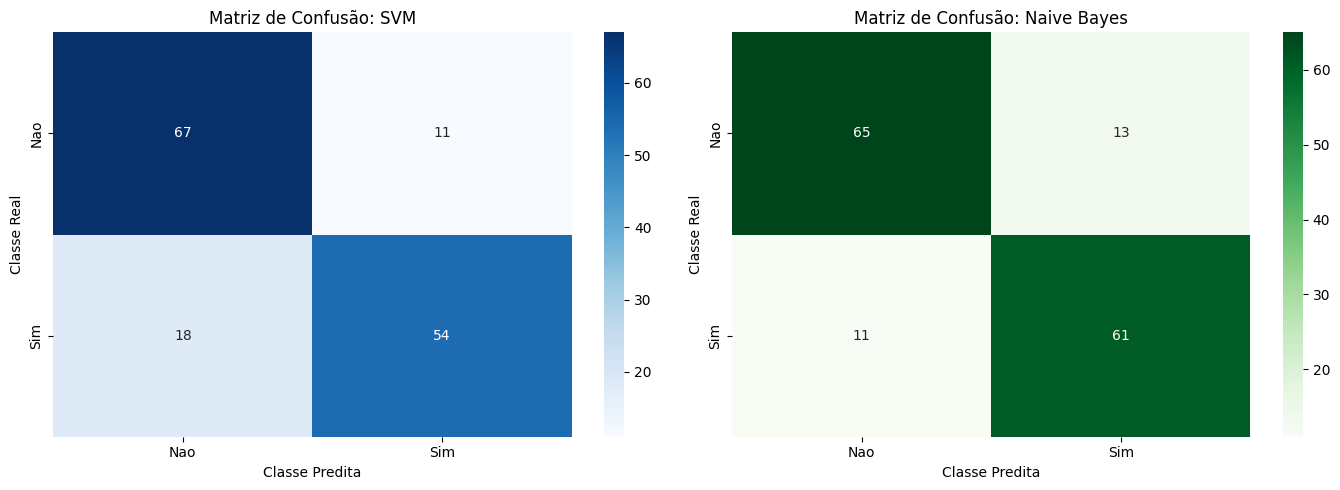

In [ ]:
# ============================================================
# 10. PLOTAGEM DAS MATRIZES DE CONFUSÃO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão para o Modelo 1
cm1 = confusion_matrix(y_test, pred_classe_mod1)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Nao', 'Sim'], yticklabels=['Nao', 'Sim'])
axes[0].set_title(f"Matriz de Confusão: {nome_mod1}")
axes[0].set_xlabel("Classe Predita")
axes[0].set_ylabel("Classe Real")

# Matriz de Confusão para o Modelo 2
cm2 = confusion_matrix(y_test, pred_classe_mod2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Nao', 'Sim'], yticklabels=['Nao', 'Sim'])
axes[1].set_title(f"Matriz de Confusão: {nome_mod2}")
axes[1].set_xlabel("Classe Predita")
axes[1].set_ylabel("Classe Real")

plt.tight_layout()
plt.show()

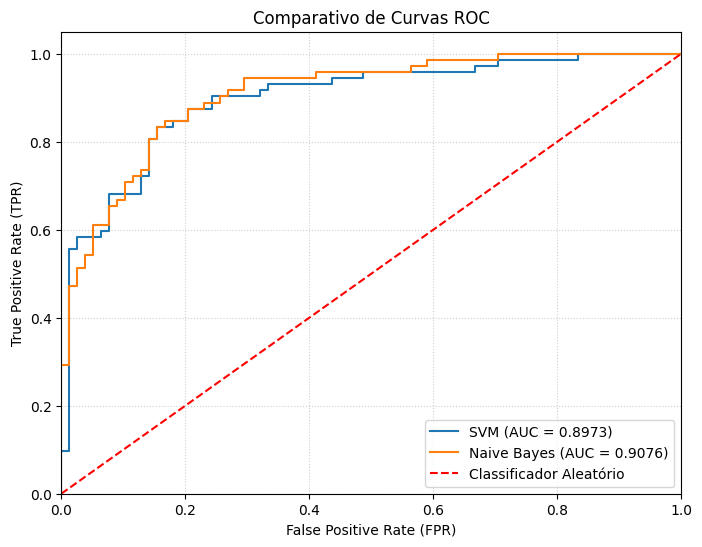

In [ ]:
# ============================================================
# 11. PLOTAGEM DAS CURVAS ROC CONSOLIDADAS
# ============================================================
fpr_mod1, tpr_mod1, _ = roc_curve(y_test, pred_proba_mod1)
fpr_mod2, tpr_mod2, _ = roc_curve(y_test, pred_proba_mod2)

auc_mod1 = metricas_mod1['AUC']
auc_mod2 = metricas_mod2['AUC']

plt.figure(figsize=(8, 6))

# Curvas de ROC de cada modelo
plt.plot(fpr_mod1, tpr_mod1, label=f"{nome_mod1} (AUC = {auc_mod1:.4f})")
plt.plot(fpr_mod2, tpr_mod2, label=f"{nome_mod2} (AUC = {auc_mod2:.4f})")

# Linha de base de referência aleatória
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Classificador Aleatório')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Comparativo de Curvas ROC')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
# ============================================================
# 12. DEMONSTRAÇÃO COM NOVOS PACIENTES (PREDIÇÃO)
# ============================================================
# Criação dos dados de 5 novos pacientes fictícios
novos_pacientes = pd.DataFrame({
    'Idade': [45, 62, 53, 38, 59],
    'Sexo': ['Masculino', 'Feminino', 'Masculino', 'Feminino', 'Masculino'],
    'DorPeito': ['Assintomatico', 'Tipica', 'Atipica', 'Sem_Dor', 'Assintomatico'],
    'PSDescanso': [125, 140, 130, 110, 150],
    'Colesterol': [210, 268, 240, 195, 310],
    'AcucarSangue': ['Normal', 'Diabetes', 'Normal', 'Normal', 'Diabetes'],
    'ECGDescanso': ['Normal', 'Hipertrofia_VE', 'Normal', 'Anormal_ST', 'Normal'],
    'BCMax': [160, 120, 145, 175, 115],
    'AnginaExercicio': ['Nao', 'Sim', 'Nao', 'Nao', 'Sim']
})

# Realizando predições com ambos os modelos
pred_classe_futuro1 = pipeline_modelo1.predict(novos_pacientes)
pred_proba_futuro1 = pipeline_modelo1.predict_proba(novos_pacientes)[:, 1]

pred_classe_futuro2 = pipeline_modelo2.predict(novos_pacientes)
pred_proba_futuro2 = pipeline_modelo2.predict_proba(novos_pacientes)[:, 1]

# Mapeamento do resultado nominal correspondente à predição
rotulo_mod1 = ['Sim' if val == 1 else 'Nao' for val in pred_classe_futuro1]
rotulo_mod2 = ['Sim' if val == 1 else 'Nao' for val in pred_classe_futuro2]

# Adicionando os outputs dinamicamente na tabela final
tabela_final = novos_pacientes.copy()

tabela_final[f'Predicao_{nome_mod1}'] = pred_classe_futuro1
tabela_final[f'Rótulo_{nome_mod1}'] = rotulo_mod1
tabela_final[f'Probabilidade_{nome_mod1}'] = pred_proba_futuro1

tabela_final[f'Predicao_{nome_mod2}'] = pred_classe_futuro2
tabela_final[f'Rótulo_{nome_mod2}'] = rotulo_mod2
tabela_final[f'Probabilidade_{nome_mod2}'] = pred_proba_futuro2

print("--- Resultados de Predição para Novos Pacientes Fictícios ---")
display(tabela_final)

--- Resultados de Predição para Novos Pacientes Fictícios ---


,Idade,Sexo,DorPeito,PSDescanso,Colesterol,AcucarSangue,ECGDescanso,BCMax,AnginaExercicio,Predicao_SVM,Rótulo_SVM,Probabilidade_SVM,Predicao_Naive Bayes,Rótulo_Naive Bayes,Probabilidade_Naive Bayes
0,45,Masculino,Assintomatico,125,210,Normal,Normal,160,Nao,0,Nao,0.307597,0,Nao,0.243127
1,62,Feminino,Tipica,140,268,Diabetes,Hipertrofia_VE,120,Sim,0,Nao,0.467690,1,Sim,0.755257
2,53,Masculino,Atipica,130,240,Normal,Normal,145,Nao,0,Nao,0.084552,0,Nao,0.000040
3,38,Feminino,Sem_Dor,110,195,Normal,Anormal_ST,175,Nao,0,Nao,0.138126,0,Nao,0.000014
4,59,Masculino,Assintomatico,150,310,Diabetes,Normal,115,Sim,1,Sim,0.881861,1,Sim,0.999999
